# Tema 1 — Visualizaciones sencillas (Matplotlib y Seaborn)

| Recurso | Fichero |
| --- | --- |
| **Ejercicios de visualización** | [`8_ejercicios_visualizaciones.md`](8_ejercicios_visualizaciones.md) |
| Dataset local | [`Datos/iris.csv`](Datos/iris.csv) |
| Dataset sintético (BMI) | generado en E5 de [`7_ejercicios_modelos.md`](7_ejercicios_modelos.md) |
| Notebook previo (datos) | [`5_lectura_de_datos.ipynb`](5_lectura_de_datos.ipynb) |
| Notebook previo (modelos) | [`6_modelos_machine_learning.ipynb`](6_modelos_machine_learning.ipynb) |
| Matplotlib | [matplotlib.org](https://matplotlib.org/stable/gallery/index.html) |
| Seaborn | [seaborn.pydata.org](https://seaborn.pydata.org/) |

Este notebook es la **referencia amplia** de visualización básica en DAVD: gráficos esenciales, buena higiene de figuras, anti-patrones y puente a **Plotly / Dash** (Tema 2).

**Cómo trabajarlo:** ejecuta en orden (`matplotlib`, `seaborn`, `pandas`).


---

## 0. Objetivos de aprendizaje

1. Elegir el tipo de gráfico según la pregunta (tendencia, distribución, comparación, composición).
2. Construir figuras claras: título, ejes, leyenda, tamaño, grid.
3. Usar Matplotlib (control fino) y Seaborn (API estadística sobre DataFrames).
4. Combinar varios paneles (`subplot` / `subplots`).
5. Visualizar datasets reales (`iris`, `flights`, `titanic`) con rutas portables.
6. Entender qué se queda en estático aquí y qué pasará a interactivo en Dash.

---


## 1. Por qué esta sesión importa en DAVD

### 1.1 Del gráfico al cuadro de mando

```text
pregunta de negocio → dato limpio → gráfico correcto → (Tema 2) interacción Dash
```

Un dashboard malo suele ser una colección de gráficos bonitos **sin pregunta**.

### 1.2 Mapa mental

```text
Matplotlib/Seaborn (hoy)  →  prototipar y comunicar
Plotly                     →  interacción rica
Dash                       →  aplicación / callbacks / despliegue
```

### 1.3 Analogías

| Gráfico | Cuándo |
| --- | --- |
| Líneas | Evolución temporal / función continua |
| Dispersión | Relación entre dos numéricas |
| Histograma | Distribución de una numérica |
| Barras | Comparar categorías |
| Boxplot | Centro, dispersión y outliers |
| Pie | Composición (úsalo con cuidado) |

### 1.4 Regla de oro

> **Primero la pregunta; después el gráfico; al final el color.**

---


## 2. Entorno e imports


In [ ]:
# Opcional si faltan dependencias en el entorno:
# %pip install matplotlib seaborn pandas numpy


In [3]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import colors

DATA_DIR = Path("Datos")
print("Datos existe:", DATA_DIR.exists())
sns.set_theme(style="whitegrid")


Matplotlib is building the font cache; this may take a moment.


Datos existe: True


---

## 3. Matplotlib — base

Documentación: [matplotlib](https://matplotlib.org/stable/contents.html) · [galería](https://matplotlib.org/stable/gallery/index.html).

### 3.1 Gráfico de líneas


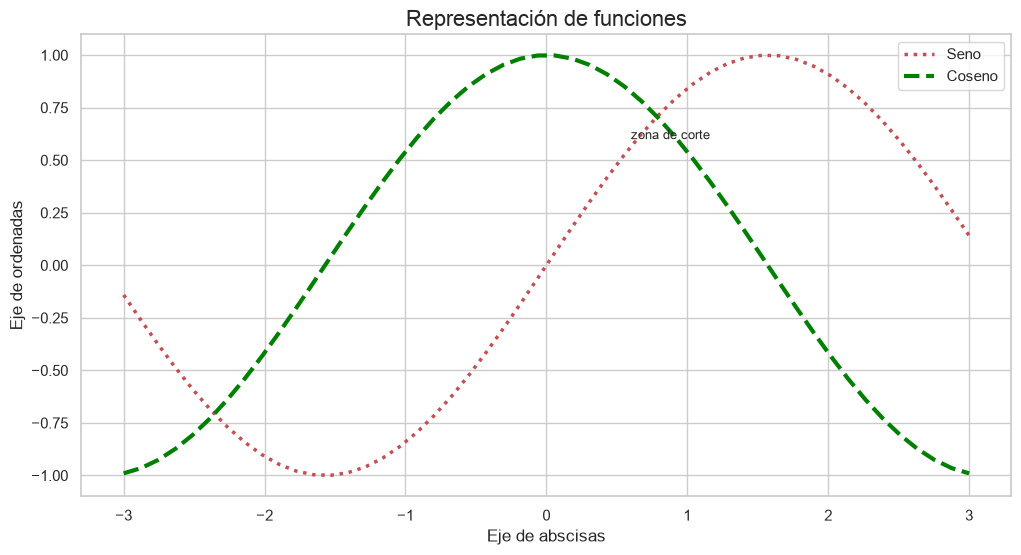

In [4]:
a = np.linspace(-3, 3, 50)
b = np.sin(a)
c_cos = np.cos(a)

plt.figure(figsize=(12, 6))
plt.plot(a, b, color="r", linewidth=2.5, linestyle=":", label="Seno")
plt.plot(a, c_cos, color="green", linewidth=3, linestyle="--", label="Coseno")
plt.xlabel("Eje de abscisas", fontsize=12)
plt.ylabel("Eje de ordenadas", fontsize=12)
plt.title("Representación de funciones", fontsize=16)
plt.text(0.6, 0.6, "zona de corte", fontsize=9)
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


Estilos de línea habituales: `'-'`, `'--'`, `'-.'`, `':'`.

Docs: [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html).

### 3.2 Dispersión (scatter)


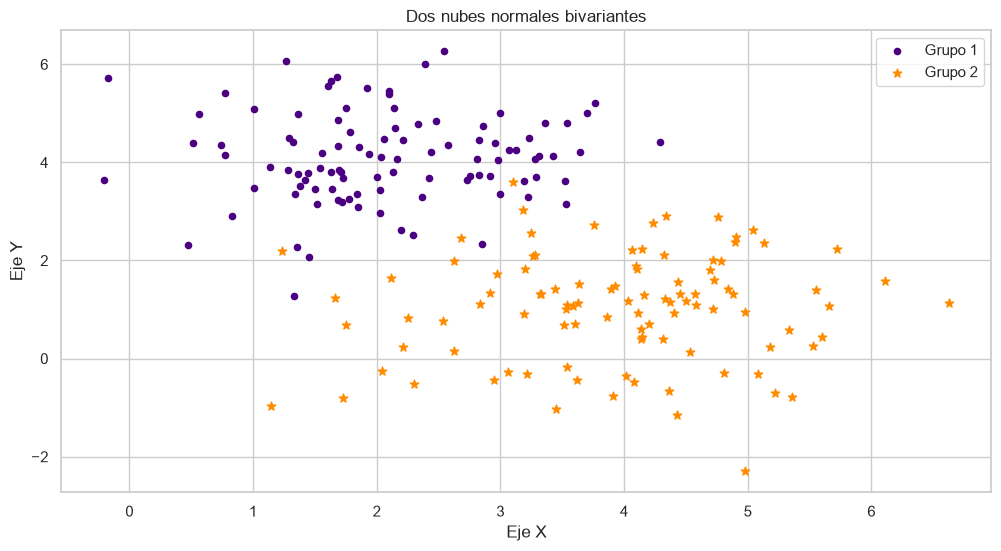

In [5]:
rng = np.random.default_rng(123)
x1 = rng.normal(loc=2, scale=1.0, size=100)
y1 = rng.normal(loc=4, scale=1.0, size=100)
x2 = rng.normal(loc=4, scale=1.0, size=100)
y2 = rng.normal(loc=1, scale=1.0, size=100)

plt.figure(figsize=(12, 6))
plt.scatter(x1, y1, c="indigo", marker=".", s=80, label="Grupo 1")
plt.scatter(x2, y2, c="darkorange", marker="*", s=40, label="Grupo 2")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.title("Dos nubes normales bivariantes")
plt.legend()
plt.grid(True)
plt.show()


Docs: [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html).

### 3.3 Histogramas


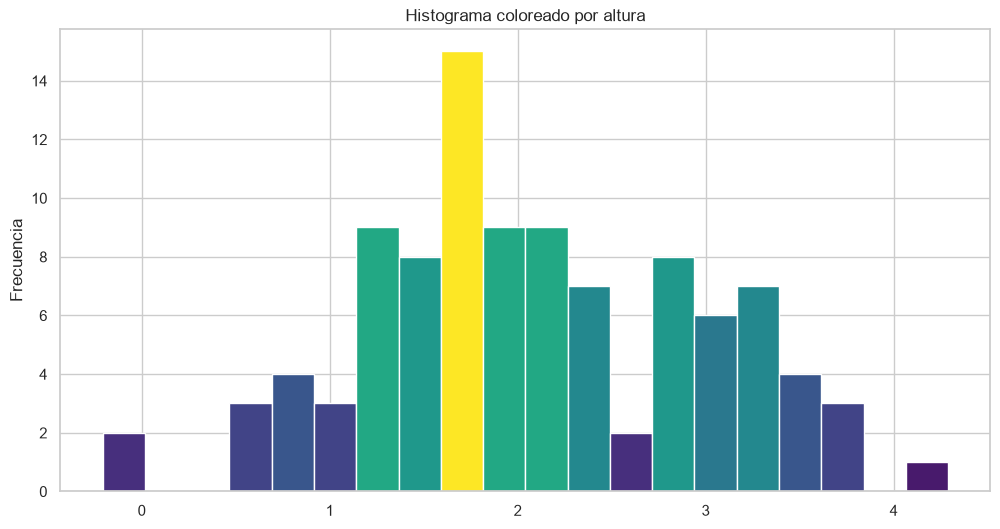

In [6]:
plt.figure(figsize=(12, 6))
N, bins, patches = plt.hist(x1, bins=20)
fracs = N / N.max()
norm = colors.Normalize(fracs.min(), fracs.max())
for thisfrac, thispatch in zip(fracs, patches):
    thispatch.set_facecolor(plt.cm.viridis(norm(thisfrac)))
plt.ylabel("Frecuencia")
plt.title("Histograma coloreado por altura")
plt.show()


In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(x1, bins=20, orientation="horizontal", color="steelblue", edgecolor="white")
plt.xlabel("Frecuencia")
plt.title("Histograma horizontal")
plt.show()


Docs: [`plt.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

### 3.4 Barras


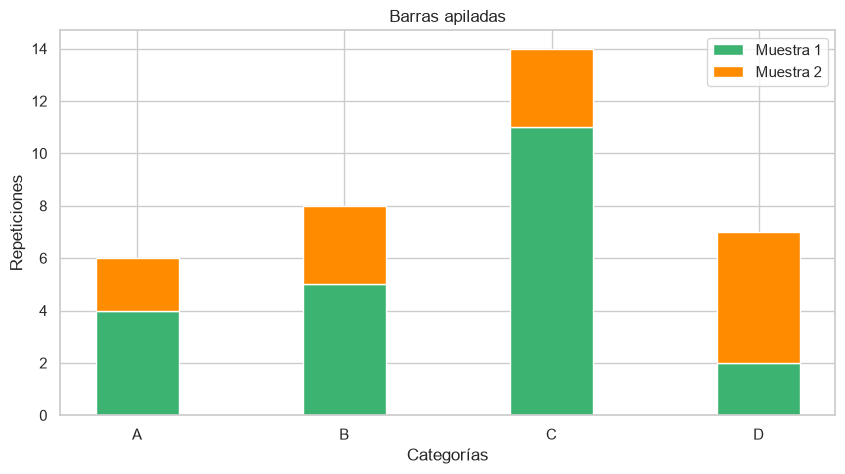

In [7]:
cat = ["A", "B", "C", "D"]
count = [4, 5, 11, 2]
count2 = [2, 3, 3, 5]

plt.figure(figsize=(10, 5))
plt.bar(cat, count, color="mediumseagreen", width=0.4, label="Muestra 1")
plt.bar(cat, count2, color="darkorange", width=0.4, bottom=count, label="Muestra 2")
plt.xlabel("Categorías")
plt.ylabel("Repeticiones")
plt.title("Barras apiladas")
plt.legend()
plt.show()


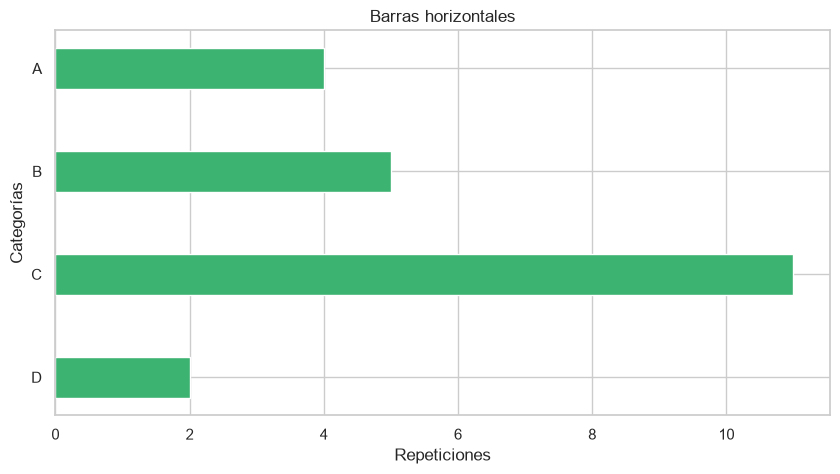

In [8]:
plt.figure(figsize=(10, 5))
plt.gca().invert_yaxis()
plt.barh(cat, count, color="mediumseagreen", height=0.4)
plt.ylabel("Categorías")
plt.xlabel("Repeticiones")
plt.title("Barras horizontales")
plt.show()


### 3.5 Boxplots


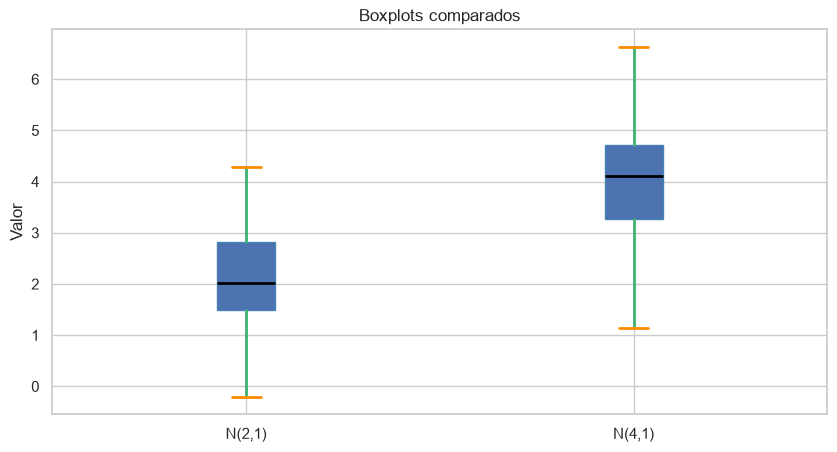

In [9]:
c1, c2, c3, c4 = "steelblue", "darkorange", "mediumseagreen", "black"

plt.figure(figsize=(10, 5))
plt.boxplot(
    np.column_stack([x1, x2]),
    positions=[1, 2],
    patch_artist=True,
    boxprops=dict(color=c1),
    capprops=dict(color=c2, linewidth=2),
    whiskerprops=dict(color=c3, linewidth=2),
    flierprops=dict(color=c1, markeredgecolor=c1),
    medianprops=dict(color=c4, linewidth=2),
)
plt.xticks([1, 2], ["N(2,1)", "N(4,1)"])
plt.title("Boxplots comparados")
plt.ylabel("Valor")
plt.show()


### 3.6 Pie chart (con criterio)

Úsalo solo con **pocas** categorías y totales que sumen el 100 % del mensaje.


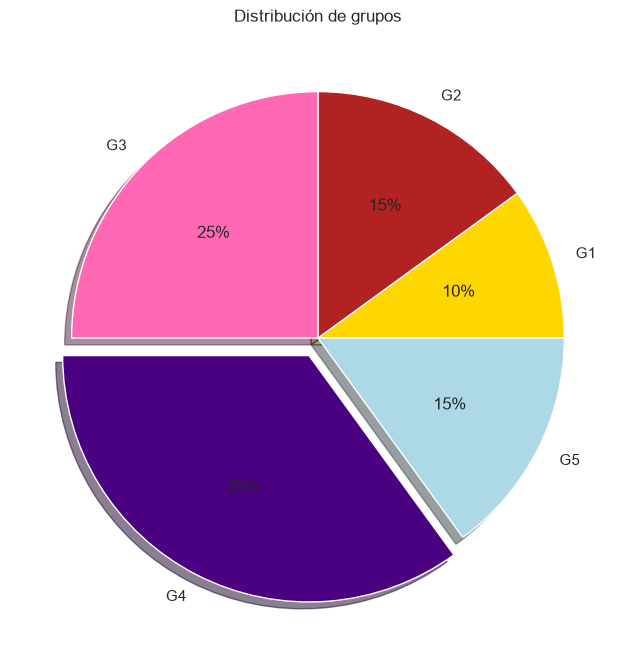

In [10]:
proporciones = [10, 15, 25, 35, 15]
grupos = ["G1", "G2", "G3", "G4", "G5"]
sep = [0, 0, 0, 0.08, 0]

plt.figure(figsize=(8, 8))
plt.pie(
    proporciones,
    labels=grupos,
    colors=["gold", "firebrick", "hotpink", "indigo", "lightblue"],
    explode=sep,
    shadow=True,
    autopct="%1.0f%%",
)
plt.title("Distribución de grupos")
plt.show()


### 3.7 Varios paneles — `subplot` y `subplots`


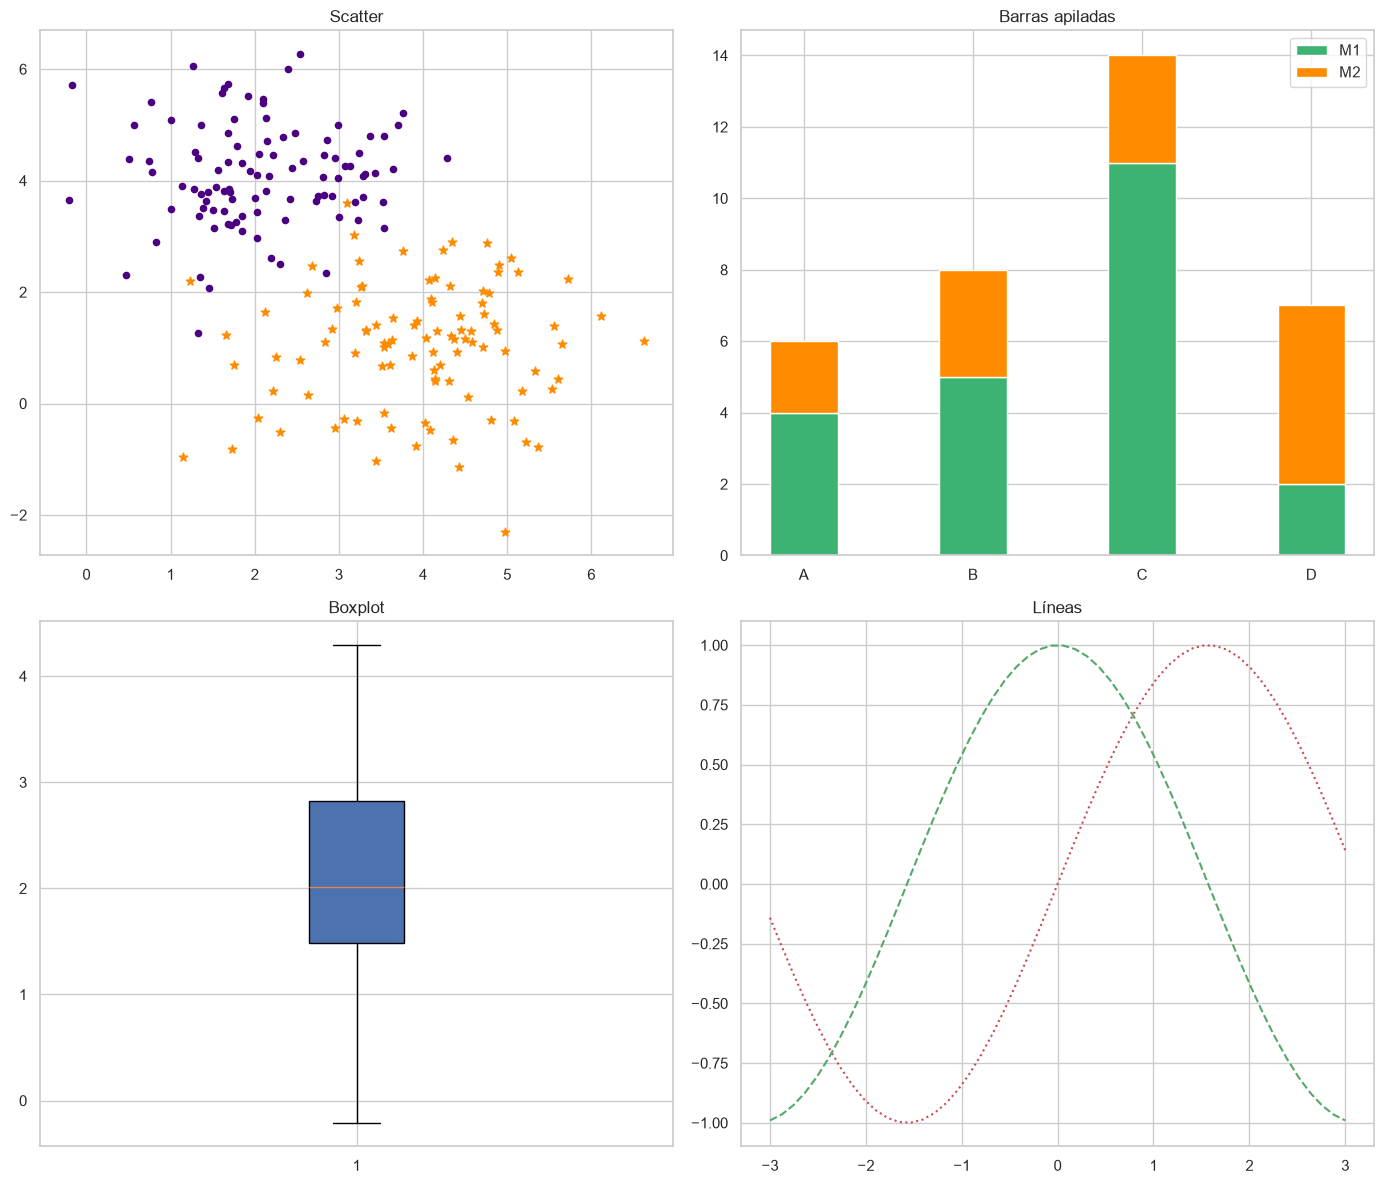

In [11]:
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
plt.scatter(x1, y1, c="indigo", marker=".", s=80)
plt.scatter(x2, y2, c="darkorange", marker="*", s=40)
plt.title("Scatter")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.bar(cat, count, color="mediumseagreen", width=0.4, label="M1")
plt.bar(cat, count2, color="darkorange", width=0.4, bottom=count, label="M2")
plt.title("Barras apiladas")
plt.legend()

plt.subplot(2, 2, 3)
plt.boxplot(x1, patch_artist=True)
plt.title("Boxplot")

plt.subplot(2, 2, 4)
plt.plot(a, b, "r:", a, c_cos, "g--")
plt.title("Líneas")
plt.grid(True)

plt.tight_layout()
plt.show()


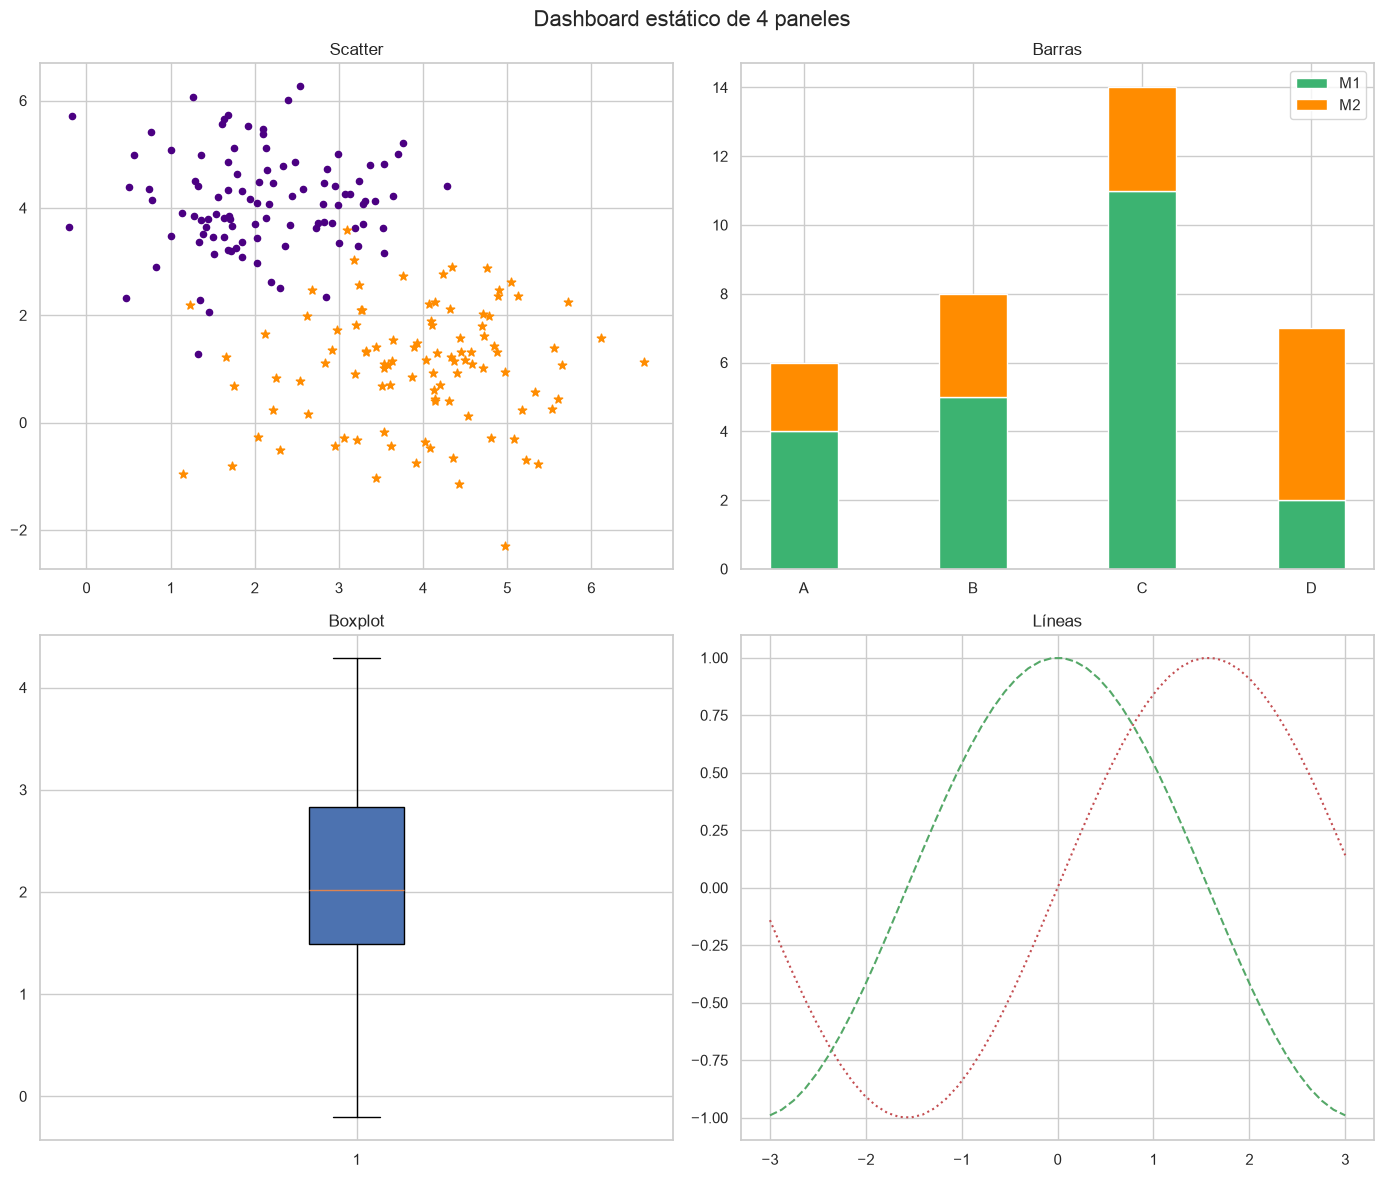

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

axs[0, 0].scatter(x1, y1, c="indigo", marker=".", s=80)
axs[0, 0].scatter(x2, y2, c="darkorange", marker="*", s=40)
axs[0, 0].set_title("Scatter")
axs[0, 0].grid(True)

axs[0, 1].bar(cat, count, color="mediumseagreen", width=0.4, label="M1")
axs[0, 1].bar(cat, count2, color="darkorange", width=0.4, bottom=count, label="M2")
axs[0, 1].set_title("Barras")
axs[0, 1].legend()

axs[1, 0].boxplot(x1, patch_artist=True)
axs[1, 0].set_title("Boxplot")

axs[1, 1].plot(a, b, "r:", a, c_cos, "g--")
axs[1, 1].set_title("Líneas")
axs[1, 1].grid(True)

fig.suptitle("Dashboard estático de 4 paneles", fontsize=16)
fig.tight_layout()
plt.show()


Docs: [`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).

---

## 4. Seaborn — DataFrames con menos fricción

Seaborn se apoya en Matplotlib y encaja muy bien con **columnas nombradas**.

### 4.1 Líneas con `flights`


In [13]:
flights = sns.load_dataset("flights")
flights.head()


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


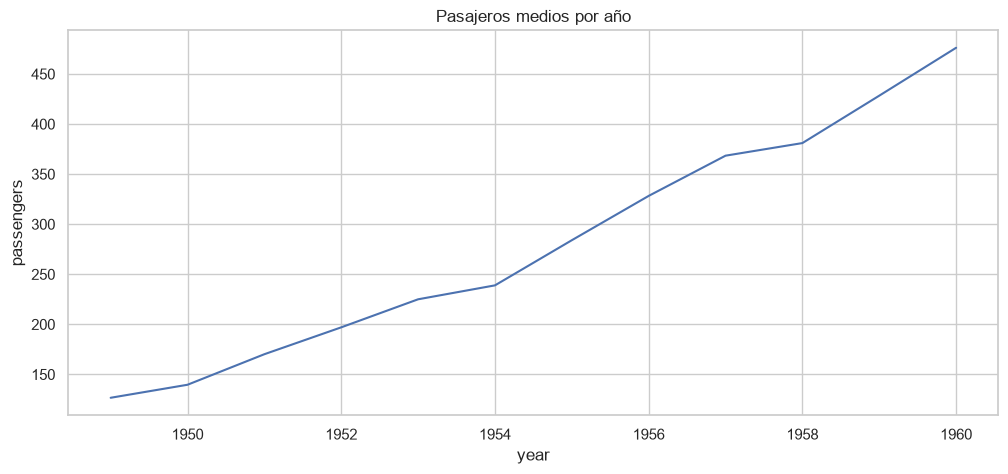

In [14]:
grouped = flights.groupby("year", as_index=False)["passengers"].mean()
plt.figure(figsize=(12, 5))
sns.lineplot(data=grouped, x="year", y="passengers")
plt.title("Pasajeros medios por año")
plt.show()


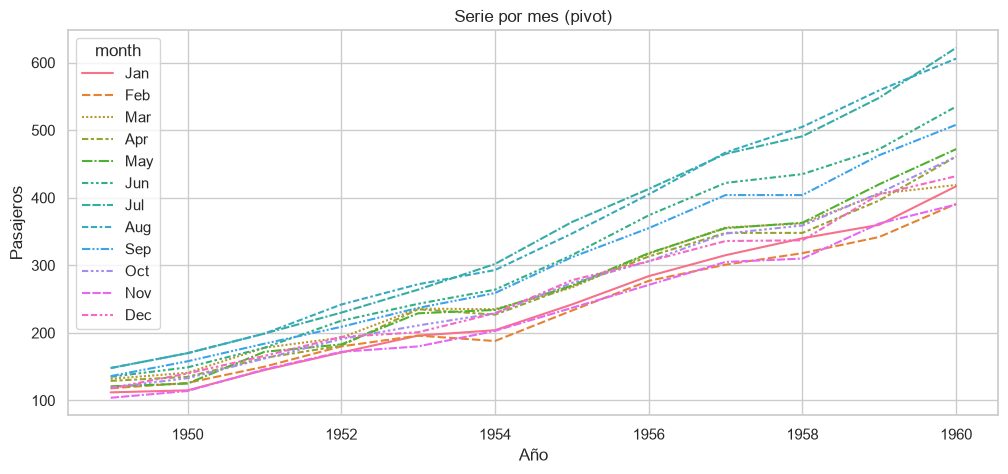

In [15]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=flights.pivot(index="year", columns="month", values="passengers"))
plt.xlabel("Año")
plt.ylabel("Pasajeros")
plt.title("Serie por mes (pivot)")
plt.show()


### 4.2 Scatter con `iris` local


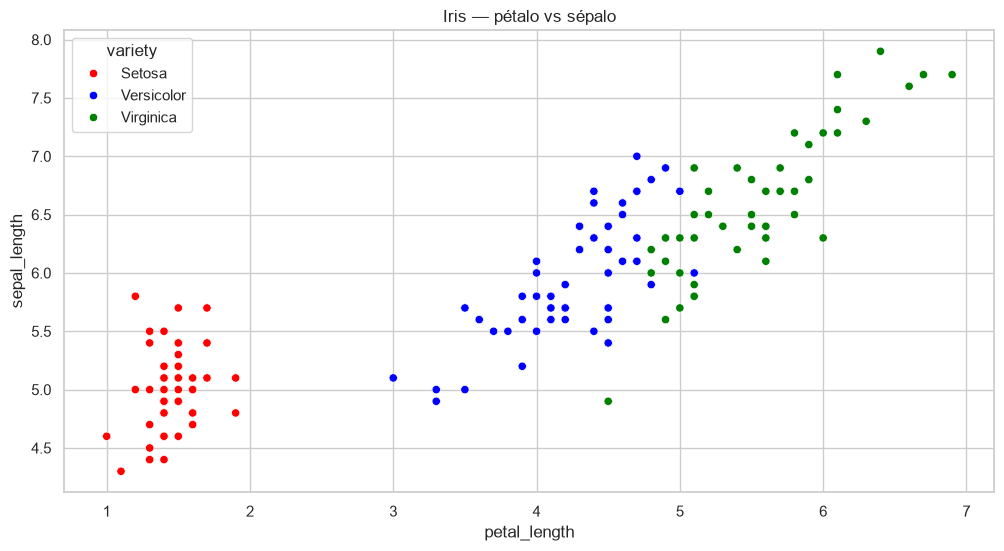

In [16]:
iris = pd.read_csv(DATA_DIR / "iris.csv")
iris.columns = [col.replace(".", "_") for col in iris.columns]

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=iris,
    x="petal_length",
    y="sepal_length",
    hue="variety",
    palette={"Setosa": "red", "Versicolor": "blue", "Virginica": "green"},
)
plt.title("Iris — pétalo vs sépalo")
plt.show()


### 4.3 Histogramas


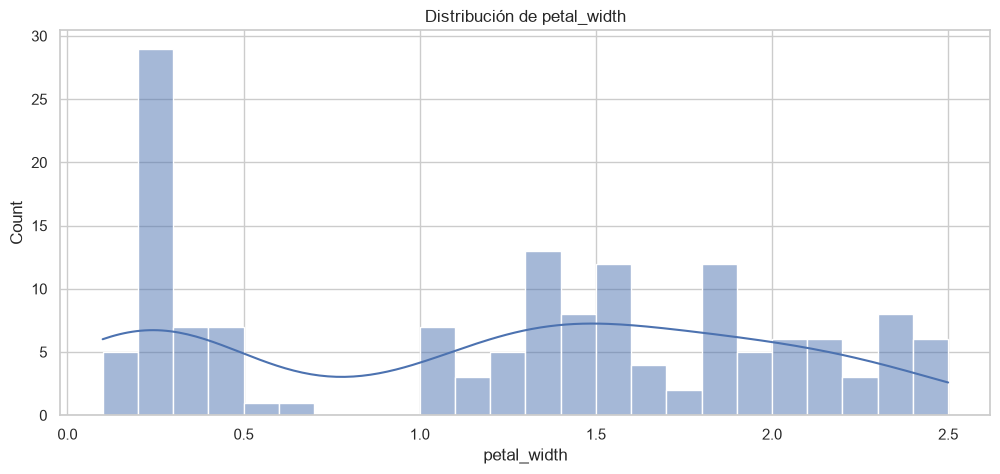

In [17]:
plt.figure(figsize=(12, 5))
sns.histplot(data=iris, x="petal_width", binwidth=0.1, kde=True)
plt.title("Distribución de petal_width")
plt.show()


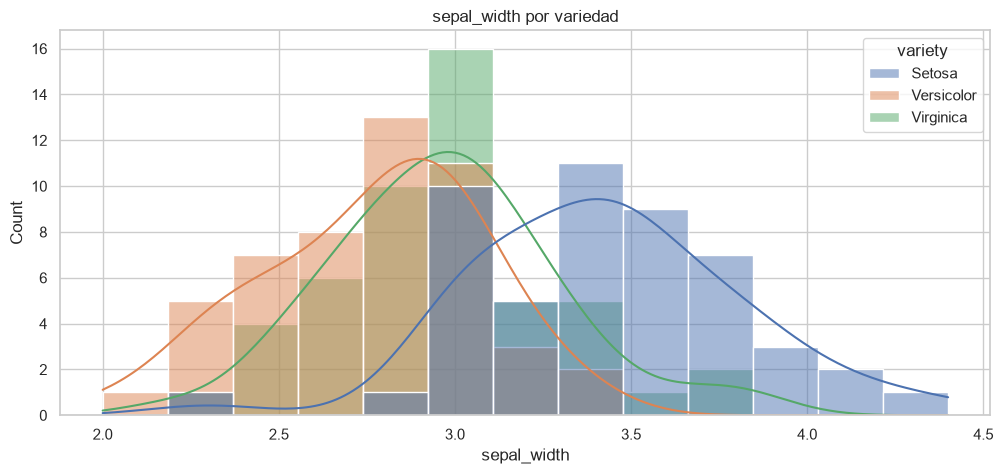

In [18]:
plt.figure(figsize=(12, 5))
sns.histplot(data=iris, x="sepal_width", hue="variety", kde=True)
plt.title("sepal_width por variedad")
plt.show()


### 4.4 Barras y conteos


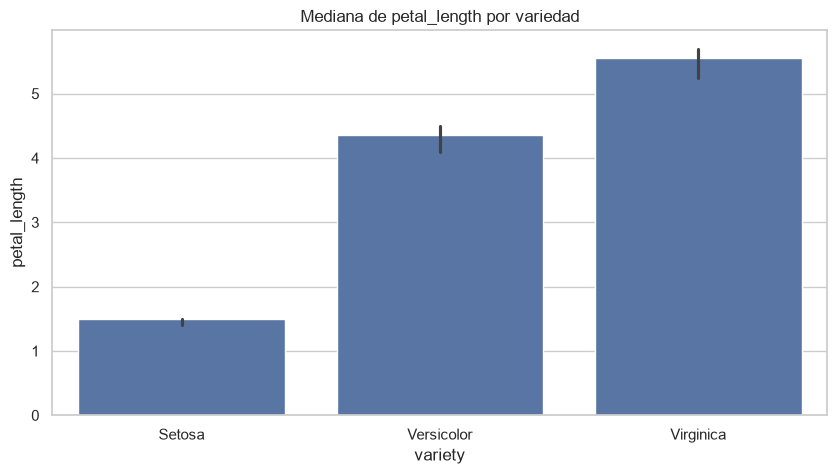

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=iris, x="variety", y="petal_length", estimator=np.median)
plt.title("Mediana de petal_length por variedad")
plt.show()


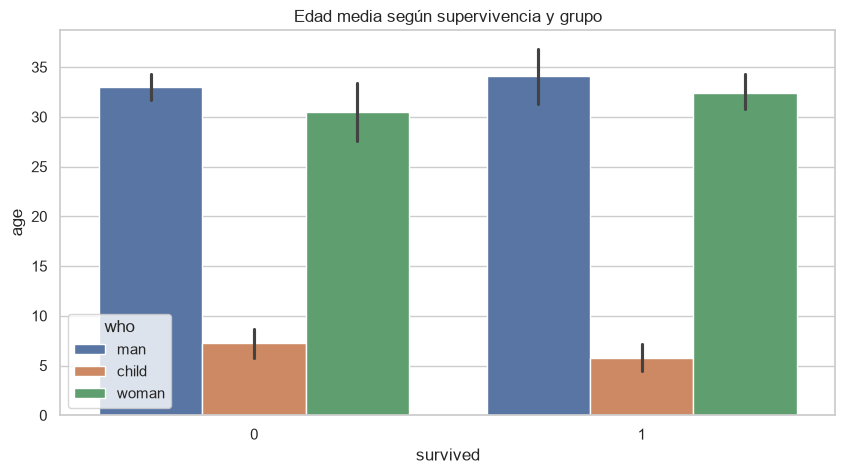

In [20]:
titanic = sns.load_dataset("titanic")
plt.figure(figsize=(10, 5))
sns.barplot(data=titanic, x="survived", y="age", hue="who", estimator=np.mean)
plt.title("Edad media según supervivencia y grupo")
plt.show()


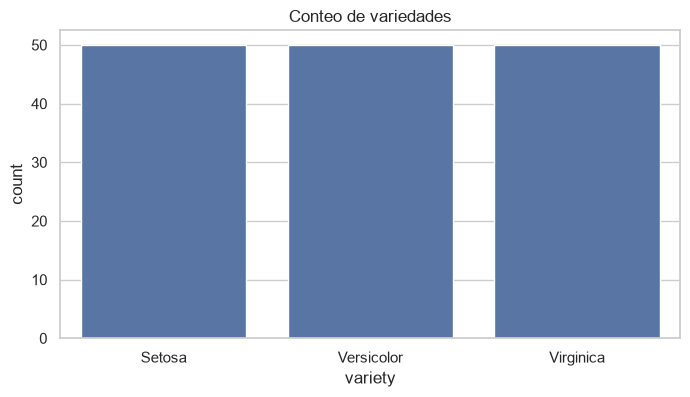

In [21]:
plt.figure(figsize=(8, 4))
sns.countplot(data=iris, x="variety")
plt.title("Conteo de variedades")
plt.show()


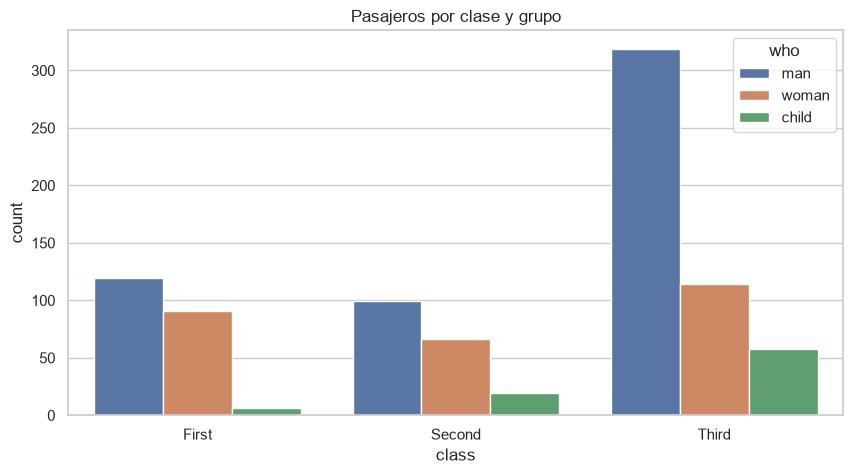

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(data=titanic, x="class", hue="who")
plt.title("Pasajeros por clase y grupo")
plt.show()


---

## 5. Mini-guía: de figura estática a Dash

| Hoy (Matplotlib/Seaborn) | Tema 2 (Plotly/Dash) |
| --- | --- |
| `plt.show()` | `dcc.Graph(figure=...)` |
| Una figura fija | Filtros + callbacks |
| Prototipo rápido | Producto interactivo |

Consejo: prototipa la **pregunta** y el **encoding** (qué va en X/Y/color) aquí; luego pásalo a Plotly sin reinventar el análisis.

---

## 6. Anti-patrones frecuentes

1. Gráfico sin título ni unidades en ejes.
2. Pie con 15 categorías.
3. Colores que no se distinguen (y sin leyenda).
4. Ejes que empiezan fuera de cero para exagerar diferencias (sin avisar).
5. Demasiados paneles sin jerarquía.
6. Rutas absolutas a CSV.
7. Visualizar antes de limpiar nulos/dtypes.
8. Copiar el estilo “arcoíris” sin significado.

---

## 7. Autoevaluación

1. ¿Líneas o barras para comparar 4 categorías en un mes?
2. ¿Scatter o histograma para ver correlación entre dos numéricas?
3. ¿Cuándo preferirías Seaborn frente a Matplotlib puro?
4. ¿Qué problema tiene un pie saturado de sectores?
5. ¿Qué llevarías tal cual a un callback de Dash?

---

## 8. Checklist de salida

- [ ] Líneas, scatter, hist, barras, boxplot y subplots ejecutados
- [ ] Iris leído desde `Datos/iris.csv`
- [ ] Al menos un gráfico Seaborn con `hue`
- [ ] Sé explicar 3 anti-patrones
- [ ] Tengo claro el puente a Plotly/Dash

---

## 9. Para la siguiente sesión (Tema 2)

1. Elige 2–3 KPIs de tu proyecto y el gráfico adecuado para cada uno.
2. Rehaz un scatter/barras de este notebook en Plotly cuando llegue el material.
3. No mezcles todavía layout HTML complejo: primero la **historia** del dato.

---

## 10. Apéndice A — Chuleta

```python
plt.figure(figsize=(10, 5))
plt.plot(x, y, label="serie")
plt.scatter(x, y, c="indigo")
plt.hist(x, bins=20)
plt.bar(cats, values)
sns.scatterplot(data=df, x="a", y="b", hue="grupo")
sns.histplot(data=df, x="a", kde=True)
plt.tight_layout(); plt.show()
```

---

## 11. Apéndice B — Glosario

| EN | ES / nota |
| --- | --- |
| axes / axis | ejes / eje |
| figure | figura completa |
| hue | color por categoría |
| bin | intervalo del histograma |
| legend | leyenda |
| subplot | panel dentro de una figura |

---

## 12. Apéndice C — Preguntas típicas

**¿Seaborn sustituye a Matplotlib?**  
No: lo complementa. A menudo Seaborn dibuja y Matplotlib termina de etiquetar.

**¿Puedo entregar el proyecto solo con Matplotlib?**  
El proyecto apunta a **Plotly/Dash**; esto es la base conceptual.

**¿Por qué `default_rng(123)`?**  
Para que el scatter sintético sea reproducible en clase.

---

## 13. Cierre

> **Elige el gráfico por la pregunta, etiquétalo bien, y deja el diseño listo para volverse interactivo.**

Siguiente paso natural: material de Plotly/Dash en `2_app_visualizaciones/`.

**Ejercicios:** practica con el dataset sintético BMI en [`8_ejercicios_visualizaciones.md`](8_ejercicios_visualizaciones.md).
